<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/cap2/lim_gibbs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import aux
importlib.reload(aux)
from aux import target_pdf_lim_gibbs

import samplers
importlib.reload(samplers)
from samplers import gibbs, random_walk_metropolis

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

/content/MCMC-MonteCarlo-TFG
Already up to date.
/content


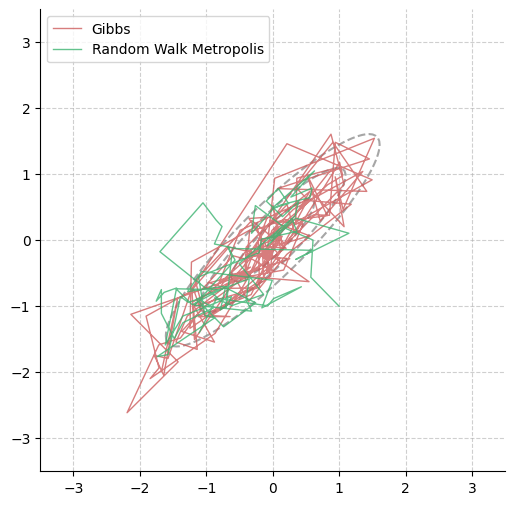

In [47]:
media = np.array([0.0, 0.0])
matriz_covarianza = np.array([[1.0, 0.9], [0.9, 1.0]])

numero_muestras = 150
inicio_gibbs = [-2.0, -2.0]
inicio_rwm = [1.0, -1.0]
sigma_propuesta = 0.5
semilla_fija = 42

funcion_objetivo = lambda x: target_pdf_lim_gibbs(x, media, matriz_covarianza)

cadena_gibbs = gibbs(media, matriz_covarianza, numero_muestras, inicio_gibbs, semilla_fija)
cadena_rwm, tasa_aceptacion = random_walk_metropolis(funcion_objetivo, numero_muestras, inicio_rwm, sigma_propuesta, semilla_fija)

figura, ejes = plt.subplots(figsize=(6, 6))

eje_x, eje_y = np.mgrid[-3.5:3.5:.05, -3.5:3.5:.05]
posiciones = np.dstack((eje_x, eje_y))

matriz_densidad = np.zeros((eje_x.shape[0], eje_x.shape[1]))
for i in range(eje_x.shape[0]):
    for j in range(eje_x.shape[1]):
        matriz_densidad[i, j] = target_pdf_lim_gibbs(posiciones[i, j], media, matriz_covarianza)

ejes.contour(eje_x, eje_y, matriz_densidad, levels=3, colors='gray', linestyles='dashed', alpha=0.7)

ejes.plot(cadena_gibbs[:, 0], cadena_gibbs[:, 1], color='indianred', lw=1, alpha=0.8, label='Gibbs')
ejes.plot(cadena_rwm[:, 0], cadena_rwm[:, 1], color='mediumseagreen', lw=1, alpha=0.8, label='Random Walk Metropolis')

ejes.set_xlim(-3.5, 3.5)
ejes.set_ylim(-3.5, 3.5)

ejes.spines['top'].set_visible(False)
ejes.spines['right'].set_visible(False)

ejes.grid(True, linestyle='--', alpha=0.6)
ejes.legend(loc='upper left', frameon=True)

plt.savefig("GIBBS.pdf")
plt.show()

In [48]:
files.download("GIBBS.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>